<a href="https://colab.research.google.com/github/suneetchugh-dev/Deep_Learning_Workshop/blob/main/DL_Image_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Introduction To Pytorch => We are using this CNN => Convolutional Neural Network

#Pytorch=> open source deep learning framework which is dynamic in nature

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3001,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)



print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))



Train Dataset Size: 60000
Test Dataset Size: 10000


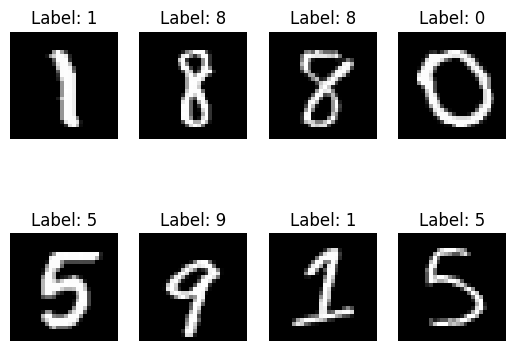

In [ ]:
images, labels = next(iter(train_loader))
for i in range(8):
  plt.subplot(2,4, i+1)
  plt.imshow(images[i].squeeze(), cmap='gray')
  plt.title(f"Label: {labels[i].item()}")
  plt.axis("off")

plt.show()

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels= 16,kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels= 16, out_channels= 16,kernel_size=3, padding=1) # FIX: in_channels should be 16

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #fully connected layer
        # Output after two pooling layers (28 -> 14 -> 7) and 16 channels from conv2
        self.fc1 = nn.Linear(16 * 7 * 7, 128) # FIX: fc1 output should be 128 for fc2
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x) # FIX: Apply pooling

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x) # Apply ReLU after fc1
        x = self.fc2(x) # Final layer, no ReLU here for CrossEntropyLoss

        return x

In [ ]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 50

train_losses_history = []
train_accuracy_history = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)


    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/50], Loss: 0.1753, Accuracy: 94.96%
Epoch [2/50], Loss: 0.0547, Accuracy: 98.27%
Epoch [3/50], Loss: 0.0392, Accuracy: 98.75%
Epoch [4/50], Loss: 0.0288, Accuracy: 99.05%
Epoch [5/50], Loss: 0.0239, Accuracy: 99.25%
Epoch [6/50], Loss: 0.0180, Accuracy: 99.40%
Epoch [7/50], Loss: 0.0144, Accuracy: 99.52%
Epoch [8/50], Loss: 0.0121, Accuracy: 99.59%
Epoch [9/50], Loss: 0.0111, Accuracy: 99.62%
Epoch [10/50], Loss: 0.0102, Accuracy: 99.67%
Epoch [11/50], Loss: 0.0080, Accuracy: 99.73%
Epoch [12/50], Loss: 0.0092, Accuracy: 99.69%
Epoch [13/50], Loss: 0.0059, Accuracy: 99.79%
Epoch [14/50], Loss: 0.0056, Accuracy: 99.80%
Epoch [15/50], Loss: 0.0080, Accuracy: 99.75%
Epoch [16/50], Loss: 0.0054, Accuracy: 99.81%
Epoch [17/50], Loss: 0.0031, Accuracy: 99.89%
Epoch [18/50], Loss: 0.0068, Accuracy: 99.79%
Epoch [19/50], Loss: 0.0058, Accuracy: 99.80%
Epoch [20/50], Loss: 0.0030, Accuracy: 99.90%
Epoch [21/50], Loss: 0.0054, Accuracy: 99.82%
Epoch [22/50], Loss: 0.0057, Accuracy: 99.7

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1,2,1)
plt.plot(train_losses_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

In [ ]:
#Image Processing Using Open CV

#Upload image using button open collab

import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
import os

print("Please Select An Image")

uploaded = files.upload()


#Get uploaded file name

image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#load Image

image = cv2.imread(image_path) #this is us reading the image using opencv

if image is None:
  raise FileNotFoundError("Image Could Not Be Loaded")

#Convert BGR to RGB

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #Converting the image to RGB since Open CV only takes images in BGR


#RESIZE IMAGE

resized = cv2.resize(image_rgb, (300,300))

#GRAYSCALE

gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)


#GAUSSIAN_BLUR

blur = cv2.GaussianBlur(gray, (5,5), 0)

#Histogram EQUALIZATION

equalized = cv2.equalizeHist(blur)


#Thresholding //This is us setting up threshold image

_, threshold_img = cv2.threshold(
    equalized,
    127,
    255,
    cv2.THRESH_BINARY
)



#EDGE DETECTION
edges = cv2.Canny(
    equalized,
    100,
    200
)


#DISPLAY ALL RESULTS

titles = [
    "Original",
    "Grayscale",
    "Gaussian Blur",
    "Histogram Equalization",
    "Threshold",
    "Edge Detection"
]


images = [
    resized,
    gray,
    blur,
    equalized,
    threshold_img,
    edges
]


plt.figure(figsize=(15,8))

for i in range(len(images)):
  plt.subplot(2,3,i+1)

  if len(images[i].shape) == 2:
    plt.imshow(images[i], cmap="gray")
  else:
    plt.imshow(images[i])

    plt.title(titles[i], fontsize=11)
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#YOLO#
!pip install ultralytics


import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


#upload image

print("="*60)
print("UPLOAD AN IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#Load pretrained YOLOv8 Models
print("\nLoading YOLOv8 Model...")
model = YOLO("yolov5x.pt")
print("Model Loaded Successfully")




#Object Detecttion
print("\nPerforming object Detetction")
results = model(image_path)
print("Detection Completed Successfully")


#Display Detected Image

result = results[0]
annotated_image = result.plot()

annotate_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.title("YLLOv8 Object Detection Result")
plt.axis("off")
plt.show()


#Print Detected Objects

print("\n" + "="*60)
print("Detected Objects")
print("="*60)

if len(result.boxes) == 0:
  print("No Objects detected")
else:

  for i, box in enumerate(result.boxes):

    cls = int(box.cls)
    confidence = float(box.conf)

    object_name = model.names[cls]

    print(f"\nObject {i+1}")
    print("-"*30)
    print(f"Class Name: {object_name}")
    print(f"Confidence: {confidence}")


    #Total Objects

    print("\n" + "="*60)
    print(f"Total Objects Detected : {len(result.boxes)}")
    print("="*60)

In [ ]:
#YOLO#
!pip install ultralytics


import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


#upload image

print("="*60)
print("UPLOAD AN IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#Load pretrained YOLOv8 Models
print("\nLoading YOLOv8 Model...")
model = YOLO("yolov8x.pt")
print("Model Loaded Successfully")




#Object Detecttion
print("\nPerforming object Detetction")
results = model(image_path)
print("Detection Completed Successfully")


#Display Detected Image

result = results[0]
annotated_image = result.plot()

annotate_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.title("YLLOv8 Object Detection Result")
plt.axis("off")
plt.show()


#Print Detected Objects

print("\n" + "="*60)
print("Detected Objects")
print("="*60)

if len(result.boxes) == 0:
  print("No Objects detected")
else:

  for i, box in enumerate(result.boxes):

    cls = int(box.cls)
    confidence = float(box.conf)

    object_name = model.names[cls]

    print(f"\nObject {i+1}")
    print("-"*30)
    print(f"Class Name: {object_name}")
    print(f"Confidence: {confidence}")


    #Total Objects

    print("\n" + "="*60)
    print(f"Total Objects Detected : {len(result.boxes)}")
    print("="*60)

In [ ]:
#SSD OBJECT DETECTION USING PYTORCH

#AIM: A traffic monitoring system needs vechicle detection\



In [ ]:
# Install required libraries

!pip -q install torch torchvision

import torch
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files



In [ ]:
#UPLOAD IMAGE

print("="*60)
print("UPLOAD TRAFFIC IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]




UPLOAD TRAFFIC IMAGE


Saving Traffic.jpg to Traffic (1).jpg


In [ ]:
#LOAD SSD MODEL

print("\nLoading SSD300 Model..")

weights = torchvision.models.detection.SSD300_VGG16_Weights.DEFAULT

model = torchvision.models.detection.ssd300_vgg16(
    weights = weights
)

model.eval()

print("Model Loaded Successfully")





Loading SSD300 Model..
Model Loaded Successfully


In [ ]:
#LOAD IMAGE


image = Image.open(image_path).convert("RGB")

transform = weights.transforms()

input_tensor = transform(image).unsqueeze(0)


In [ ]:
#OBJECT DETECTTION

with torch.no_grad():

  prediction = model(input_tensor)[0]




In [ ]:
#COCO CLASS NAMES

COCO_CLASSES = [
'__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
'snowboard', 'sports ball', 'kite', 'baseball bat',
'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

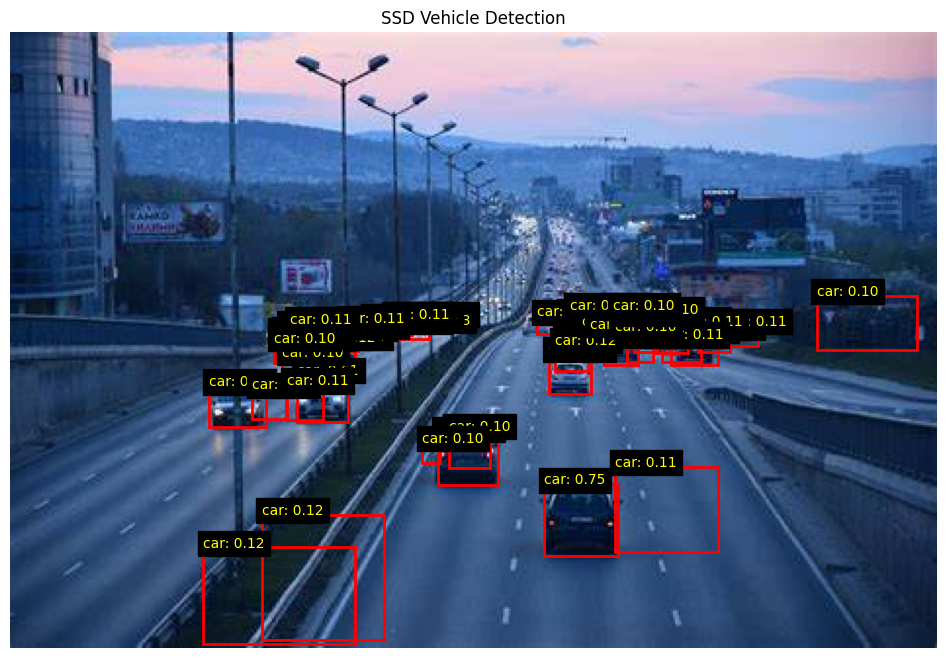

In [ ]:
#DISPLAY RESULT

fig, ax = plt.subplots(figsize=(12,8))

ax.imshow(image)

vehicle_classes = ["car", "truck", "bus", "motorcycle", "bicycle"]

count = 0

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]):

    # Only process detections with score > 0.10
    if score > 0.10:
        cls = COCO_CLASSES[label]

        if cls in vehicle_classes:

            xmin, ymin, xmax, ymax = box.tolist()

            rect = patches.Rectangle(
                (xmin, ymin),
                xmax-xmin,
                ymax-ymin,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)

            ax.text(
                xmin,
                ymin,
                f"{cls}: {score:.2f}",
                color="yellow",
                fontsize=10,
                backgroundcolor="black"
            )

            count += 1

plt.title("SSD Vehicle Detection")
plt.axis("off")
plt.show()

In [ ]:
#PRINT DETECTED VEHICLES

print("\n", "="*60)

print("Detected Vehicles")

print("="*60)

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]):

  if score > 0.10:
    cls = COCO_CLASSES[label]

    if cls in vehicle_classes:

      print(f"Vehicle: {cls}")
      print(f"Confidence: {score:.2f}")
      print("-"*30)

print(f"\nTotal Vehicles Detected:  {count}")



Detected Vehicles
Vehicle: car
Confidence: 0.75
------------------------------
Vehicle: car
Confidence: 0.73
------------------------------
Vehicle: car
Confidence: 0.61
------------------------------
Vehicle: car
Confidence: 0.53
------------------------------
Vehicle: car
Confidence: 0.36
------------------------------
Vehicle: car
Confidence: 0.28
------------------------------
Vehicle: car
Confidence: 0.23
------------------------------
Vehicle: car
Confidence: 0.22
------------------------------
Vehicle: car
Confidence: 0.18
------------------------------
Vehicle: car
Confidence: 0.17
------------------------------
Vehicle: car
Confidence: 0.17
------------------------------
Vehicle: car
Confidence: 0.16
------------------------------
Vehicle: car
Confidence: 0.15
------------------------------
Vehicle: car
Confidence: 0.15
------------------------------
Vehicle: car
Confidence: 0.14
------------------------------
Vehicle: car
Confidence: 0.14
------------------------------
Vehic

In [ ]:
#Fine Tuniong using ResNet50 on CIFAR-10 (PyTorch)
#import required libraries


import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models


import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

In [ ]:
#Image Processing

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_dataset = torchvision

Device : cuda


In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root = "./data",

    train = True,
    download = True,
    transform = transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root="./data",

    train = False,

    download = True,

    transform = transform
)

 45%|████▍     | 76.0M/170M [18:11<22:37, 69.6kB/s]

In [ ]:
#Create DataLoader


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)




NameError: name 'torch' is not defined

In [ ]:
#Learning RNN
import torch
import torch.nn as nn
import torch.optim as optim




X = torch.tensor([
    [1,2,3],
    [2,3,4],
    [3,4,5],
    [4,5,6]
], dtype=torch.float32)

y = torch.tensor(
    [
      [4],
      [5],
      [6],
      [7]
    ], dtype=torch.float32)


#Reshape Input
#Shape = (samples, time_steps, features)


X = X.unsqueeze(-1)

print("Input Shape :", X.shape)
print("Target Shape :", y.shape)



#Build Simple RNN Model


class SimpleRNN(nn.Module):

  def __init__(self):

    super(SimpleRNN, self). __init__()

    self.rnn = nn.RNN(
        input_size = 1,
        num_layers = 1,
        hidden_size = 50,
        batch_first = True
    )


    self.fc = nn.Linear(50,1)


  def forward(self, x):

    output, hidden = self.rnn(x)

    #take output of last time step
    out = output[:,-1, :]

    out = self.fc(out)

    return out

model = SimpleRNN()


#Loss function and Optimizer


criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)


#Train the Model

epochs = 500

for epoch in range(epochs):

  optimizer.zero_grad()
  outputs = model(X)

  loss = criterion(outputs, y)

  loss.backward()

  optimizer.step()

  if (epoch+1) % 50 == 0:
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


#Test the Model

test_input = torch.tensor(
[
    [5.0],
    [6.0],
    [7.0]
], dtype=torch.float32)

test_input = test_input.unsqueeze(0)

model.eval()

with torch.no_grad():

  prediction = model(test_input)

print("\nPrediction Next Numbers:", prediction.item())


Input Shape : torch.Size([4, 3, 1])
Target Shape : torch.Size([4, 1])
Epoch [50/500], Loss: 1.1712
Epoch [100/500], Loss: 0.0759
Epoch [150/500], Loss: 0.0006
Epoch [200/500], Loss: 0.0000
Epoch [250/500], Loss: 0.0000
Epoch [300/500], Loss: 0.0000
Epoch [350/500], Loss: 0.0000
Epoch [400/500], Loss: 0.0000
Epoch [450/500], Loss: 0.0000
Epoch [500/500], Loss: 0.0000

Prediction Next Numbers: 7.252762317657471


In [ ]:
#Example 2: Weather Forecasting System using RNN


import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
temperature = np.array(
    [
        30,31,32,33,34,
        35,36,35,34,33,
        32,31,30,29,28,
        29,30,31,32,33
    ], dtype=np.float32
)

In [ ]:
sequence_length = 3
X = []
Y = []

for i in range(len(temperature)-sequence_length):

  X.append(temperature[i+1:i+sequence_length+1])
  Y.append(temperature[i+sequence_length])

X = np.array(X)
Y = np.array(Y)

print("Input Shape :", X.shape)
print("Target Shape :", Y.shape)


Input Shape : (17, 3)
Target Shape : (17,)


In [ ]:
Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)

print(X.shape)
print(Y.shape)





(17, 3)
torch.Size([17, 1, 1, 1])


/tmp/ipykernel_700/2095425524.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)


In [ ]:
# ==========================================
# Learning RNN with PyTorcha
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim


# ==========================================
# Create Dataset
# ==========================================

# Input sequences
X = torch.tensor([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6]
], dtype=torch.float32)

# Target outputs
y = torch.tensor([
    [4],
    [5],
    [6],
    [7]
], dtype=torch.float32)


# ==========================================
# Reshape Input
# Shape = (samples, time_steps, features)
# ==========================================

X = X.unsqueeze(-1)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


# ==========================================
# Build Simple RNN Model
# ==========================================

class WeatherRNN(nn.Module):

    def __init__(self):
        super(WeatherRNN, self).__init__()

        # RNN Layer
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(16, 1)

    def forward(self, x):

        # Pass input through RNN
        output, hidden = self.rnn(x)

        # Take output from the last time step
        out = output[:, -1, :]

        # Pass through Fully Connected layer
        out = self.fc(out)

        return out


# ==========================================
# Create Model
# ==========================================

model = WeatherRNN()


# ==========================================
# Loss Function and Optimizer
# ==========================================

# Mean Squared Error Loss
criterion = nn.MSELoss()

# Adam Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)


# ==========================================
# Train the Model
# ==========================================

epochs = 500

for epoch in range(epochs):

    # Forward Pass
    prediction = model(X)

    # Compute Loss
    loss = criterion(prediction, y)

    # Clear Previous Gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update Weights
    optimizer.step()

    # Print Loss every 50 Epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] Loss: {loss.item():.4f}")


# ==========================================
# Test on Training Data
# ==========================================

model.eval()

with torch.no_grad():

    predicted = model(X)

print("\nActual vs Predicted")
print("-" * 30)

for actual, pred in zip(y, predicted):
    print(f"Actual: {actual.item():.2f}    Predicted: {pred.item():.2f}")


# ==========================================
# Test on New Data
# ==========================================

test_input = torch.tensor([
    [5.0],
    [6.0],
    [7.0]
], dtype=torch.float32)

# Add batch dimension
test_input = test_input.unsqueeze(0)

model.eval()

with torch.no_grad():

    next_prediction = model(test_input)

print("\nPrediction for [5, 6, 7] ->", next_prediction.item())

Input Shape : torch.Size([4, 3, 1])
Target Shape: torch.Size([4, 1])
Epoch [50/500] Loss: 1.4007
Epoch [100/500] Loss: 1.2141
Epoch [150/500] Loss: 0.4970
Epoch [200/500] Loss: 0.0134
Epoch [250/500] Loss: 0.0006
Epoch [300/500] Loss: 0.0000
Epoch [350/500] Loss: 0.0000
Epoch [400/500] Loss: 0.0000
Epoch [450/500] Loss: 0.0000
Epoch [500/500] Loss: 0.0000

Actual vs Predicted
------------------------------
Actual: 4.00    Predicted: 4.00
Actual: 5.00    Predicted: 5.00
Actual: 6.00    Predicted: 6.00
Actual: 7.00    Predicted: 7.00

Prediction for [5, 6, 7] -> 7.243900775909424


In [ ]:
# ==========================================
# Implemeting GRU NN Architecture with Previous Code
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim


# ==========================================
# Create Dataset
# ==========================================

# Input sequences
X = torch.tensor([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6]
], dtype=torch.float32)

# Target outputs
y = torch.tensor([
    [4],
    [5],
    [6],
    [7]
], dtype=torch.float32)


# ==========================================
# Reshape Input
# Shape = (samples, time_steps, features)
# ==========================================

X = X.unsqueeze(-1)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


# ==========================================
# Build Simple RNN Model
# ==========================================

class ChatbotGRU(nn.Module):

    def __init__(self):
        super(ChatbotGRU, self).__init__()

        # RNN Layer
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            num_layers=1,
            batch_first=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        # Pass input through RNN
        output, hidden = self.gru(x)

        # Take output from the last time step
        out = output[:, -1, :]

        # Pass through Fully Connected layer
        out = self.fc(out)

        return out


# ==========================================
# Create Model
# ==========================================

model = ChatbotGRU()


# ==========================================
# Loss Function and Optimizer
# ==========================================

# Mean Squared Error Loss
criterion = nn.MSELoss()

# Adam Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)


# ==========================================
# Train the Model
# ==========================================

epochs = 500

for epoch in range(epochs):

    # Forward Pass
    prediction = model(X)

    # Compute Loss
    loss = criterion(prediction, y)

    # Clear Previous Gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update Weights
    optimizer.step()

    # Print Loss every 50 Epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] Loss: {loss.item():.4f}")


# ==========================================
# Test on Training Data
# ==========================================

model.eval()

with torch.no_grad():

    predicted = model(X)

print("\nActual vs Predicted")
print("-" * 30)

for actual, pred in zip(y, predicted):
    print(f"Actual: {actual.item():.2f}    Predicted: {pred.item():.2f}")


# ==========================================
# Test on New Data
# ==========================================

test_input = torch.tensor([
    [5.0],
    [6.0],
    [7.0]
], dtype=torch.float32)

# Add batch dimension
test_input = test_input.unsqueeze(0)

model.eval()

with torch.no_grad():

    next_prediction = model(test_input)

print("\nPrediction for [5, 6, 7] ->", next_prediction.item())

Input Shape : torch.Size([4, 3, 1])
Target Shape: torch.Size([4, 1])
Epoch [50/500] Loss: 1.1102
Epoch [100/500] Loss: 0.2032
Epoch [150/500] Loss: 0.0008
Epoch [200/500] Loss: 0.0000
Epoch [250/500] Loss: 0.0000
Epoch [300/500] Loss: 0.0000
Epoch [350/500] Loss: 0.0000
Epoch [400/500] Loss: 0.0000
Epoch [450/500] Loss: 0.0000
Epoch [500/500] Loss: 0.0000

Actual vs Predicted
------------------------------
Actual: 4.00    Predicted: 4.00
Actual: 5.00    Predicted: 5.00
Actual: 6.00    Predicted: 6.00
Actual: 7.00    Predicted: 7.00

Prediction for [5, 6, 7] -> 7.205354690551758


In [ ]:
# ==========================================
# Implemeting LSTM NN Architecture with Previous Code
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim


# ==========================================
# Create Dataset
# ==========================================

# Input sequences
X = torch.tensor([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6]
], dtype=torch.float32)

# Target outputs
y = torch.tensor([
    [4],
    [5],
    [6],
    [7]
], dtype=torch.float32)


# ==========================================
# Reshape Input
# Shape = (samples, time_steps, features)
# ==========================================

X = X.unsqueeze(-1)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


# ==========================================
# Build Simple RNN Model
# ==========================================

class ChatbotLSTM(nn.Module):

    def __init__(self):
        super(ChatbotLSTM, self).__init__()

        # RNN Layer
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=1,
            batch_first=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        # Pass input through RNN
        output, (hidden, cell) = self.lstm(x)

        # Take output from the last time step
        out = output[:, -1, :]

        # Pass through Fully Connected layer
        out = self.fc(out)

        return out


# ==========================================
# Create Model
# ==========================================

model = ChatbotLSTM()


# ==========================================
# Loss Function and Optimizer
# ==========================================

# Mean Squared Error Loss
criterion = nn.MSELoss()

# Adam Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)


# ==========================================
# Train the Model
# ==========================================

epochs = 500

for epoch in range(epochs):

    # Forward Pass
    prediction = model(X)

    # Compute Loss
    loss = criterion(prediction, y)

    # Clear Previous Gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update Weights
    optimizer.step()

    # Print Loss every 50 Epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] Loss: {loss.item():.4f}")


# ==========================================
# Test on Training Data
# ==========================================

model.eval()

with torch.no_grad():

    predicted = model(X)

print("\nActual vs Predicted")
print("-" * 30)

for actual, pred in zip(y, predicted):
    print(f"Actual: {actual.item():.2f}    Predicted: {pred.item():.2f}")


# ==========================================
# Test on New Data
# ==========================================

test_input = torch.tensor([
    [5.0],
    [6.0],
    [7.0]
], dtype=torch.float32)

# Add batch dimension
test_input = test_input.unsqueeze(0)

model.eval()

with torch.no_grad():

    next_prediction = model(test_input)

print("\nPrediction for [5, 6, 7] ->", next_prediction.item())

Input Shape : torch.Size([4, 3, 1])
Target Shape: torch.Size([4, 1])
Epoch [50/500] Loss: 1.1621
Epoch [100/500] Loss: 0.5925
Epoch [150/500] Loss: 0.0030
Epoch [200/500] Loss: 0.0000
Epoch [250/500] Loss: 0.0000
Epoch [300/500] Loss: 0.0000
Epoch [350/500] Loss: 0.0000
Epoch [400/500] Loss: 0.0000
Epoch [450/500] Loss: 0.0000
Epoch [500/500] Loss: 0.0000

Actual vs Predicted
------------------------------
Actual: 4.00    Predicted: 4.00
Actual: 5.00    Predicted: 5.00
Actual: 6.00    Predicted: 6.00
Actual: 7.00    Predicted: 7.00

Prediction for [5, 6, 7] -> 7.3216142654418945


cpu

Training Started 

Epoch [1/10], Loss: 0.03860071075679079
Epoch [2/10], Loss: 0.01759722649649993
Epoch [3/10], Loss: 0.013010074957402975
Epoch [4/10], Loss: 0.01080738468322037
Epoch [5/10], Loss: 0.00942483227223412
Epoch [6/10], Loss: 0.008526528868744812
Epoch [7/10], Loss: 0.007891633133314598
Epoch [8/10], Loss: 0.00740667208751191
Epoch [9/10], Loss: 0.006966590592419224
Epoch [10/10], Loss: 0.006604544963361993

 Training Completed


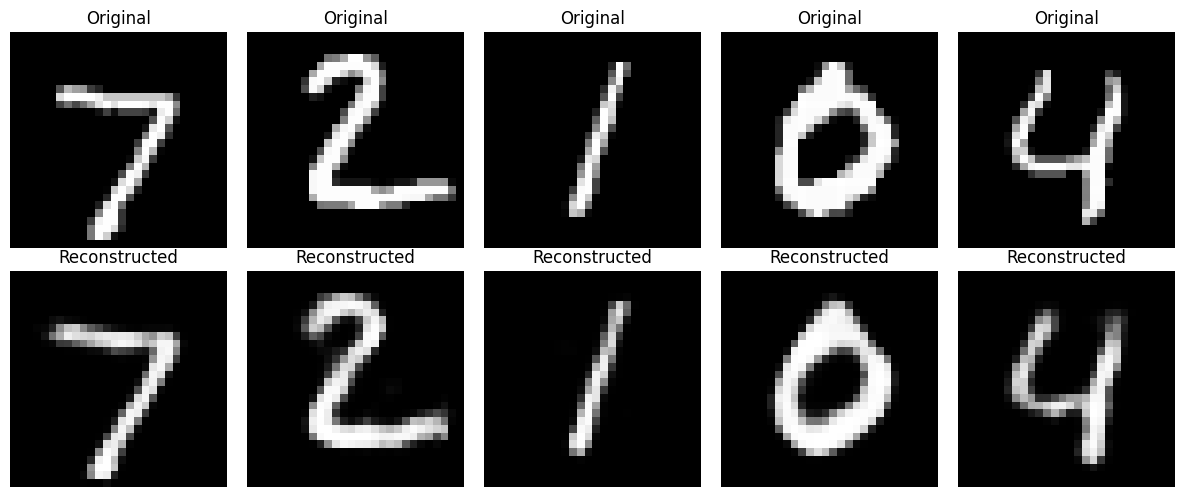


 Feature Reduction
------------------------------------------------------
Original Feature Size:  784
Reduced Feature Size:  64
------------------------------------------------------

Compressed Feature vector of first Image


Shape of Compressed Features: torch.Size([64, 64])


In [ ]:
from torch.nn.modules.container import Sequential
#Import Libraries

import torch
import torch.nn as nn

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


#Device Configuragtion

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)



#Load MNIST Dataset

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)


#Define AutoEncoder Model

class AutoEncoder(nn.Module):

  def __init__(self):
    super(AutoEncoder, self).__init__()

    #Encoder (Feature Reduction)

    self.encoder = nn.Sequential(
      nn.Linear(784,256),
      nn.ReLU(),

      nn.Linear(256,128),
      nn.ReLU(),

      nn.Linear(128,64)
    )


    #Decoder (Image Reconstruction)

    self.decoder = nn.Sequential(
        nn.Linear(64,128),
        nn.ReLU(),

        nn.Linear(128,256),
        nn.ReLU(),

        nn.Linear(256,784),
        nn.Sigmoid()
    )



  def forward(self,x):

    x = x.view(-1, 784)
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return encoded, decoded



#Create Model

model = AutoEncoder().to(device)


#Define Loss Function and Optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


#Train Model

epochs = 10

print("\nTraining Started \n")

for epoch in range(epochs):

  running_loss = 0

  for images, _ in train_loader:
    images = images.to(device)

    images = images.view(-1,784)


    optimizer.zero_grad()

    encoded_output, outputs = model(images)

    loss = criterion(outputs, images)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader)}")


print("\n Training Completed")





#Test The Model


images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

  encoded_features, reconstructed = model(images)

reconstructed = reconstructed.view(-1,1,28,28)



#Display Original And Reconstucted Images

plt.figure(figsize=(12,5))

for i in range(5):

  plt.subplot(2,5,i+1)
  plt.imshow(images[i].cpu().numpy().reshape(28,28), cmap="gray")
  plt.title("Original")
  plt.axis("off")


#Reconstructed Images

for i in range(5):
  plt.subplot(2,5,i+6)
  plt.imshow(reconstructed[i].cpu().detach().numpy().reshape(28,28), cmap="gray")
  plt.title("Reconstructed")
  plt.axis("off")

plt.tight_layout()
plt.show()


#Feature Reduction


print("\n Feature Reduction")

print("------------------------------------------------------")

print("Original Feature Size: ", 784)
print("Reduced Feature Size: ", encoded_features.shape[1])
print("------------------------------------------------------")


print("\nCompressed Feature vector of first Image\n")

print("\nShape of Compressed Features:", encoded_features.shape)

using device:  cpu

Training Started 

Epoch [1/10], Loss: 0.06008846885455189
Epoch [2/10], Loss: 0.03265682126540365
Epoch [3/10], Loss: 0.026487201916923653
Epoch [4/10], Loss: 0.022800549654278166
Epoch [5/10], Loss: 0.02037023948326802
Epoch [6/10], Loss: 0.01853487910682967
Epoch [7/10], Loss: 0.01727172273046363
Epoch [8/10], Loss: 0.01647792792896917
Epoch [9/10], Loss: 0.01576753306204576
Epoch [10/10], Loss: 0.015168657145107478

 Training Completed


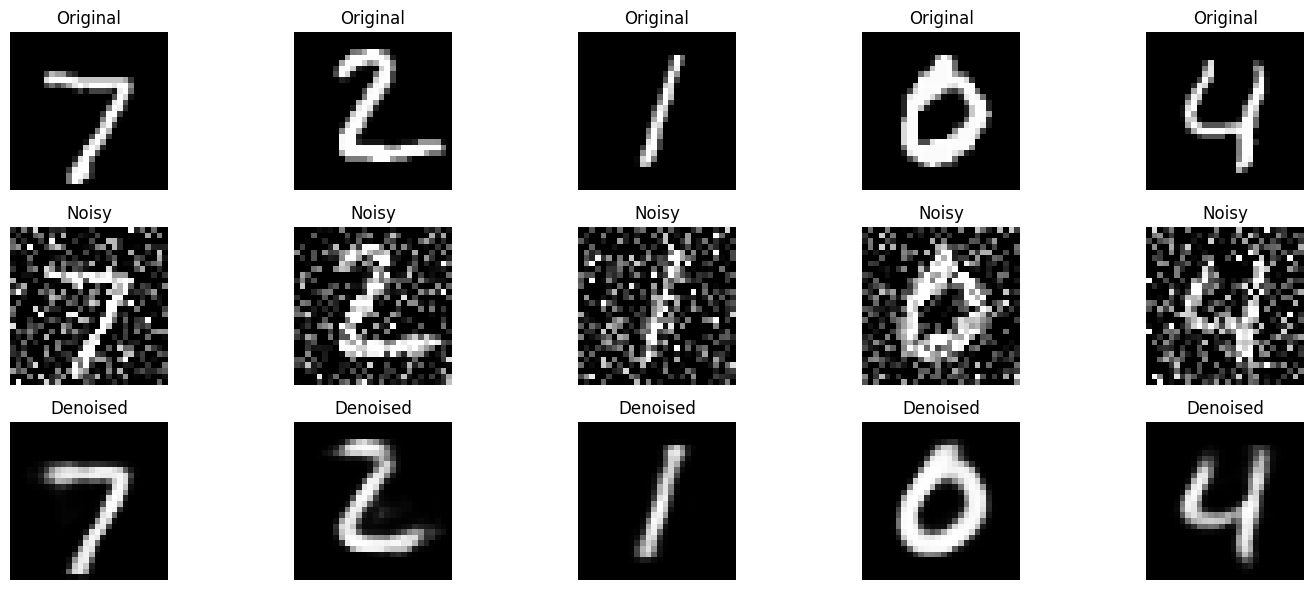

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device: ",device)
#Load MNIST DATASET
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = True,
    transform = transform,
    download = True)
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train = False,
    transform = transform,
    download = True
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_Loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=10,
    shuffle=False
)
#Function to add gaussian noise
def add_noise(images, noise_factor=0.4):
  noisy = images + noise_factor * torch.randn_like(images)
  noisy = torch.clamp(noisy, 0., 1.) # Clamping values between 0 and 1
  return noisy


#Define Denoising AutoEncoder

class DenoisingAutoEncoder(nn.Module):

  def __init__(self):
    super(DenoisingAutoEncoder, self).__init__()

    #Encoder
    self.encoder = nn.Sequential(
      nn.Linear(784,256),
      nn.ReLU(),

      nn.Linear(256,128),
      nn.ReLU(),

      nn.Linear(128,64)
    )


    #Decoder

    self.decoder = nn.Sequential(
        nn.Linear(64,128),
        nn.ReLU(),

        nn.Linear(128,256),
        nn.ReLU(),

        nn.Linear(256,784),
        nn.Sigmoid()
    )

  def forward(self,x):
    x = x.view(-1, 784)
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return encoded, decoded



#Create Model

model = DenoisingAutoEncoder().to(device)


#Define Loss Function and Optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Training
epochs = 10
print("\nTraining Started \n")

for epoch in range(epochs):
  running_loss = 0

  for images, _ in train_loader:

    images = images.to(device)
    noisy_images = add_noise(images)

    noisy_images_flat = noisy_images.view(-1,784)

    clean_images = images.view(-1,784)

    optimizer.zero_grad()

    encoded_output, decoded_output = model(noisy_images_flat)

    loss = criterion(decoded_output, clean_images)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader)}")

print("\n Training Completed")



#Testing

images, labels = next(iter(test_Loader))

images = images.to(device)

with torch.no_grad():

  noisy_images_test = add_noise(images)
  encoded_features, reconstructed = model(noisy_images_test)

reconstructed = reconstructed.view(-1,1,28,28)

#Display Results

plt.figure(figsize=(15,6))

#Original Image
for i in range(5):
  plt.subplot(3,5,i+1)
  plt.imshow(images[i].cpu().numpy().reshape(28,28), cmap="gray")
  plt.title("Original")
  plt.axis("off")

#Noisy Image
for i in range(5):
  plt.subplot(3,5,i+6) # i+6 for second row
  plt.imshow(noisy_images_test[i].cpu().numpy().reshape(28,28), cmap="gray")
  plt.title("Noisy")
  plt.axis("off")

#Denoised Image
for i in range(5):
  plt.subplot(3,5,i+11) # i+11 for third row
  plt.imshow(reconstructed[i].cpu().detach().numpy().reshape(28,28), cmap="gray")
  plt.title("Denoised")
  plt.axis("off")

plt.tight_layout()
plt.show()

Using Device: cpu

Training Started 

Epoch [1/10], Loss: 163.6215
Epoch [2/10], Loss: 121.2665
Epoch [3/10], Loss: 114.5233
Epoch [4/10], Loss: 111.6304
Epoch [5/10], Loss: 109.8748
Epoch [6/10], Loss: 108.7969
Epoch [7/10], Loss: 107.9347
Epoch [8/10], Loss: 107.2787
Epoch [9/10], Loss: 106.8059
Epoch [10/10], Loss: 106.3768

Training Completed


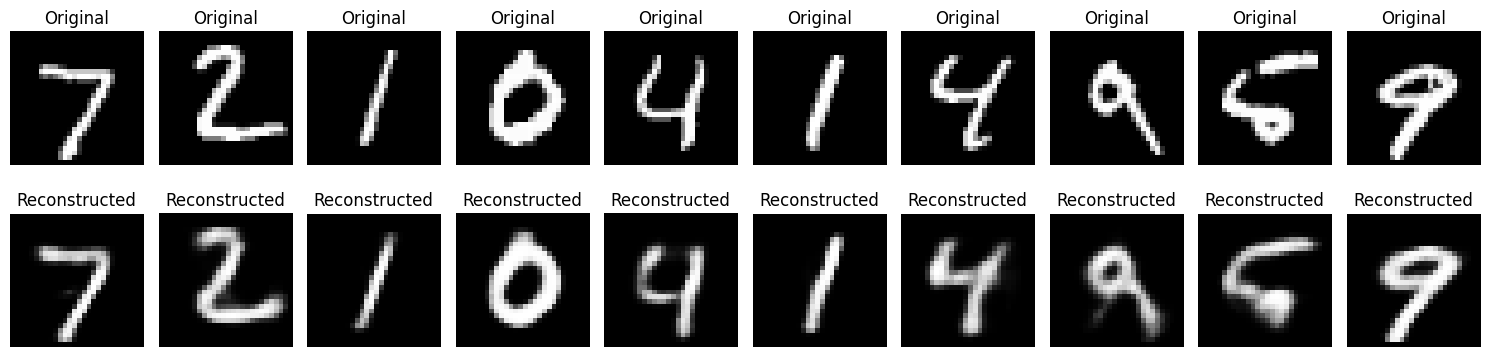

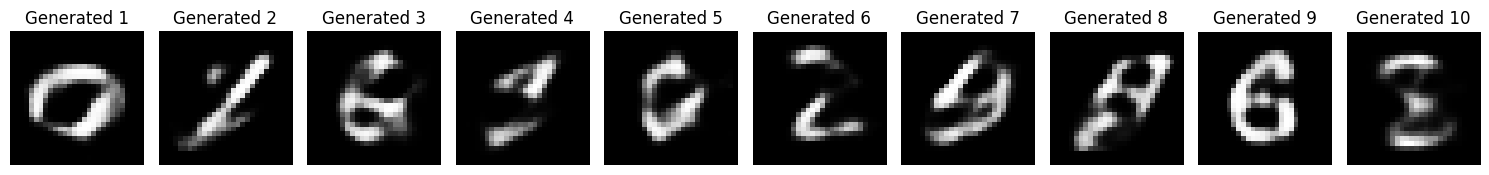

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

#device configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

#load MNIST dataset

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True

)

# Data loaders
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=128,
    shuffle=False
)


#variational Autoencoder Model

class VAE(nn.Module):
  def __init__(self):
    super(VAE, self).__init__()

    #Encoder
    self.fc1 = nn.Linear(784, 400)
    self.fc21 = nn.Linear(400, 20) # Mean
    self.fc22 = nn.Linear(400, 20) # Log variance

    #Decoder
    self.fc3 = nn.Linear(20, 400)
    self.fc4 = nn.Linear(400, 784)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encode(self, x):
    h1 = self.relu(self.fc1(x))
    return self.fc21(h1), self.fc22(h1)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h3 = self.relu(self.fc3(z))
    return self.sigmoid(self.fc4(h3))

  def forward(self, x):
    x = x.view(-1, 784)
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar


# VAE Loss Function
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


# Create Model
model = VAE().to(device)


# Define Loss Function and Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# Training Loop
epochs = 10
print("\nTraining Started \n")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss / len(train_loader.dataset):.4f}")

print("\nTraining Completed")

# Testing and Visualization
model.eval()
with torch.no_grad():
    # Get a batch of test images
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    # Reconstruct images
    reconstructed_images, _, _ = model(test_images)
    reconstructed_images = reconstructed_images.view(-1, 1, 28, 28)

    # Display original and reconstructed images
    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 4))
    for i in range(10):
        # Original images
        axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title('Original')

        # Reconstructed images
        axes[1, i].imshow(reconstructed_images[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title('Reconstructed')

    plt.tight_layout()
    plt.show()


    model.eval()
with torch.no_grad():
    # Generate random latent vectors
    num_generate = 10
    # The latent dimension (20) comes from self.fc21 and self.fc22 in VAE's __init__
    random_z = torch.randn(num_generate, 20).to(device)

    # Decode the latent vectors to generate new images
    generated_images = model.decode(random_z).cpu()
    generated_images = generated_images.view(-1, 1, 28, 28)

    # Display the generated images
    fig_gen, axes_gen = plt.subplots(nrows=1, ncols=num_generate, figsize=(15, 2))
    for i in range(num_generate):
        axes_gen[i].imshow(generated_images[i].squeeze(), cmap='gray')
        axes_gen[i].axis('off')
        axes_gen[i].set_title(f'Generated {i+1}')

    plt.tight_layout()
    plt.show()